# MACHINE LEARNING — Phân tích dự đoán thị trường điện tử Tiki

> **Câu hỏi nghiên cứu**: Phân hóa thị trường giữa **Global Brand** vs **OEM/Local Generic**
>
> **3 mô hình**: Random Forest (Classification) · Linear Regression · K-Means (Clustering)
>
> **Notebook này triển khai theo đặc tả**: `ML.MD`

In [1]:
# ============================================================
# CELL 1: Import thu vien & Cau hinh
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, r2_score, mean_squared_error,
                             mean_absolute_error, silhouette_score)
from sklearn.decomposition import PCA

# Cau hinh hien thi
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12
})
sns.set_style("whitegrid")

# Bang mau nhat quan
BRAND_COLORS = {
    'Global_Brand': '#2196F3',
    'Local_Generic': '#FF9800',
    'OEM_Generic': '#9C27B0'
}
BRAND_ORDER = ['Global_Brand', 'Local_Generic', 'OEM_Generic']
BRAND_LABELS = {
    'Global_Brand': 'Global Brand',
    'Local_Generic': 'Local Generic',
    'OEM_Generic': 'OEM Generic'
}

# Doc du lieu
df = pd.read_csv('../data/tiki_electronics_2026_processed.csv')
print(f"Da nap du lieu: {df.shape[0]:,} san pham x {df.shape[1]} truong")
print(f"Brand types: {df['brand_type'].value_counts().to_dict()}")
print(f"Purchase status: {df['purchase_status'].value_counts().to_dict()}")

Da nap du lieu: 11,668 san pham x 20 truong
Brand types: {'Local_Generic': 6906, 'Global_Brand': 4605, 'OEM_Generic': 157}
Purchase status: {'new_listing': 6049, 'has_sales': 5619}


---
## ML1: Random Forest Classifier — Phân loại Brand Type

> **Mục tiêu**: Dự đoán sản phẩm thuộc nhóm thương hiệu nào dựa trên đặc trưng thị trường
>
> **Ý nghĩa**: Xác định **yếu tố nào phân biệt rõ nhất** giữa Global Brand và Local Generic
>
> **Lý do chọn RF**: Cung cấp Feature Importance trực quan, robust với outlier, không cần chuẩn hóa
>
> **Liên kết**: Hỗ trợ kết luận MT1 (thị phần), MT2 (price premium), MT6 (dominance danh mục)

In [2]:
# ============================================================
# ML1 - Buoc 1: Chuan bi du lieu cho Random Forest
# ============================================================

# Drop row co brand_name missing
df_ml = df.dropna(subset=['brand_name']).copy()

# === Target ===
y_rf = df_ml['brand_type']

# === Features ===
# Encode category_name (fit tren TRAIN sau, nhung tao cot truoc)
le_cat = LabelEncoder()
df_ml['category_encoded'] = le_cat.fit_transform(df_ml['category_name'])

# Encode purchase_status (binary)
df_ml['purchase_binary'] = (df_ml['purchase_status'] == 'has_sales').astype(int)

# Encode discount_flag (ordinal)
disc_map = {'no_discount': 0, 'normal_discount': 1, 'extreme_discount': 2}
df_ml['discount_encoded'] = df_ml['discount_flag'].map(disc_map)

# Encode boolean columns
df_ml['is_rating_suspect_int'] = df_ml['is_rating_suspect'].astype(int)
df_ml['is_fake_discount_int'] = df_ml['is_fake_discount'].astype(int)

# Feature list
feature_cols = [
    'price', 'original_price', 'discount_rate',
    'rating_average', 'review_count', 'quantity_sold',
    'is_tiki_trading', 'is_rating_suspect_int', 'is_fake_discount_int',
    'category_encoded', 'discount_encoded', 'purchase_binary'
]

X_rf = df_ml[feature_cols]

print(f"Features shape: {X_rf.shape}")
print(f"Target distribution:\n{y_rf.value_counts()}")
print(f"\nFeature columns: {feature_cols}")

Features shape: (11667, 12)
Target distribution:
brand_type
Local_Generic    6906
Global_Brand     4605
OEM_Generic       156
Name: count, dtype: int64

Feature columns: ['price', 'original_price', 'discount_rate', 'rating_average', 'review_count', 'quantity_sold', 'is_tiki_trading', 'is_rating_suspect_int', 'is_fake_discount_int', 'category_encoded', 'discount_encoded', 'purchase_binary']


In [3]:
# ============================================================
# ML1 - Buoc 2: Chia du lieu Train/Valid/Test (60/20/20)
# ============================================================

# Buoc 2a: Tach TEST 20% truoc (khong dung den khi chot model)
X_tv_rf, X_test_rf, y_tv_rf, y_test_rf = train_test_split(
    X_rf, y_rf, test_size=0.20, random_state=42, stratify=y_rf
)

# Buoc 2b: Tu 80% con lai, tach VALID 25% (= 20% tong the)
X_train_rf, X_val_rf, y_train_rf, y_val_rf = train_test_split(
    X_tv_rf, y_tv_rf, test_size=0.25, random_state=42, stratify=y_tv_rf
)

print("=" * 60)
print("CHIEN LUOC CHIA DU LIEU ML1 — RANDOM FOREST")
print("=" * 60)
print(f"Tong mau:  {len(X_rf):,}")
print(f"TRAIN set: {len(X_train_rf):,} ({len(X_train_rf)/len(X_rf)*100:.1f}%)")
print(f"VALID set: {len(X_val_rf):,} ({len(X_val_rf)/len(X_rf)*100:.1f}%)")
print(f"TEST set:  {len(X_test_rf):,} ({len(X_test_rf)/len(X_rf)*100:.1f}%)")

print(f"\n--- Phan phoi brand_type trong moi tap (stratified) ---")
for name, y_set in [('TRAIN', y_train_rf), ('VALID', y_val_rf), ('TEST', y_test_rf)]:
    dist = y_set.value_counts(normalize=True) * 100
    print(f"{name}: Global={dist.get('Global_Brand',0):.1f}% | "
          f"Local={dist.get('Local_Generic',0):.1f}% | "
          f"OEM={dist.get('OEM_Generic',0):.1f}%")

CHIEN LUOC CHIA DU LIEU ML1 — RANDOM FOREST
Tong mau:  11,667
TRAIN set: 6,999 (60.0%)
VALID set: 2,334 (20.0%)
TEST set:  2,334 (20.0%)

--- Phan phoi brand_type trong moi tap (stratified) ---
TRAIN: Global=39.5% | Local=59.2% | OEM=1.3%
VALID: Global=39.5% | Local=59.2% | OEM=1.3%
TEST: Global=39.5% | Local=59.2% | OEM=1.3%


In [4]:
# ============================================================
# ML1 - Buoc 3: Huan luyen & Theo doi Overfit tren VALID
# ============================================================

# Theo doi accuracy theo n_estimators de chon sieu tham so
n_est_range = [50, 100, 150, 200, 250, 300]
train_accs = []
val_accs = []

print("=" * 60)
print("THEO DOI OVERFIT — Train vs Valid Accuracy")
print("=" * 60)
print(f"{'n_estimators':>12} | {'Train Acc':>10} | {'Valid Acc':>10} | {'Gap':>8}")
print("-" * 50)

for n in n_est_range:
    rf = RandomForestClassifier(
        n_estimators=n, random_state=42,
        class_weight='balanced', n_jobs=-1
    )
    rf.fit(X_train_rf, y_train_rf)
    
    acc_train = accuracy_score(y_train_rf, rf.predict(X_train_rf))
    acc_val = accuracy_score(y_val_rf, rf.predict(X_val_rf))
    train_accs.append(acc_train)
    val_accs.append(acc_val)
    gap = acc_train - acc_val
    print(f"{n:>12} | {acc_train:>10.4f} | {acc_val:>10.4f} | {gap:>+8.4f}")

# Chon n_estimators co Valid Acc cao nhat
best_idx = np.argmax(val_accs)
best_n = n_est_range[best_idx]
print(f"\n=> Chon n_estimators = {best_n} (Valid Acc = {val_accs[best_idx]:.4f})")
print(f"   Gap train-valid = {train_accs[best_idx] - val_accs[best_idx]:+.4f} ", end="")
if abs(train_accs[best_idx] - val_accs[best_idx]) < 0.05:
    print("(< 5% => KHONG overfit)")
elif abs(train_accs[best_idx] - val_accs[best_idx]) < 0.10:
    print("(< 10% => overfit NHE)")
else:
    print("(>= 10% => overfit NANG)")

# Fit model cuoi cung voi best_n
rf_model = RandomForestClassifier(
    n_estimators=best_n, random_state=42,
    class_weight='balanced', n_jobs=-1
)
rf_model.fit(X_train_rf, y_train_rf)

THEO DOI OVERFIT — Train vs Valid Accuracy
n_estimators |  Train Acc |  Valid Acc |      Gap
--------------------------------------------------
          50 |     0.9706 |     0.7515 |  +0.2191
         100 |     0.9714 |     0.7541 |  +0.2174
         150 |     0.9714 |     0.7549 |  +0.2165
         200 |     0.9710 |     0.7554 |  +0.2156
         250 |     0.9710 |     0.7571 |  +0.2139
         300 |     0.9710 |     0.7558 |  +0.2152

=> Chon n_estimators = 250 (Valid Acc = 0.7571)
   Gap train-valid = +0.2139 (>= 10% => overfit NANG)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",250
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [5]:
# ============================================================
# ML1 - Buoc 4: DANH GIA CUOI CUNG tren TEST SET (1 lan duy nhat)
# ============================================================

y_pred_test_rf = rf_model.predict(X_test_rf)
y_pred_val_rf = rf_model.predict(X_val_rf)

acc_test = accuracy_score(y_test_rf, y_pred_test_rf)
acc_val_final = accuracy_score(y_val_rf, y_pred_val_rf)
acc_train_final = accuracy_score(y_train_rf, rf_model.predict(X_train_rf))

print("=" * 60)
print("BAO CAO CUOI CUNG — RANDOM FOREST (TEST SET)")
print("=" * 60)
print(f"Train Accuracy: {acc_train_final:.4f}")
print(f"Valid Accuracy: {acc_val_final:.4f}")
print(f"TEST Accuracy:  {acc_test:.4f}")
print(f"Gap (train-test): {acc_train_final - acc_test:+.4f}")
print(f"\n--- Classification Report (TEST) ---\n")
print(classification_report(y_test_rf, y_pred_test_rf, target_names=BRAND_ORDER))

BAO CAO CUOI CUNG — RANDOM FOREST (TEST SET)
Train Accuracy: 0.9710
Valid Accuracy: 0.7571
TEST Accuracy:  0.7678
Gap (train-test): +0.2032

--- Classification Report (TEST) ---

               precision    recall  f1-score   support

 Global_Brand       0.72      0.72      0.72       921
Local_Generic       0.81      0.82      0.81      1382
  OEM_Generic       0.12      0.10      0.11        31

     accuracy                           0.77      2334
    macro avg       0.55      0.54      0.55      2334
 weighted avg       0.77      0.77      0.77      2334



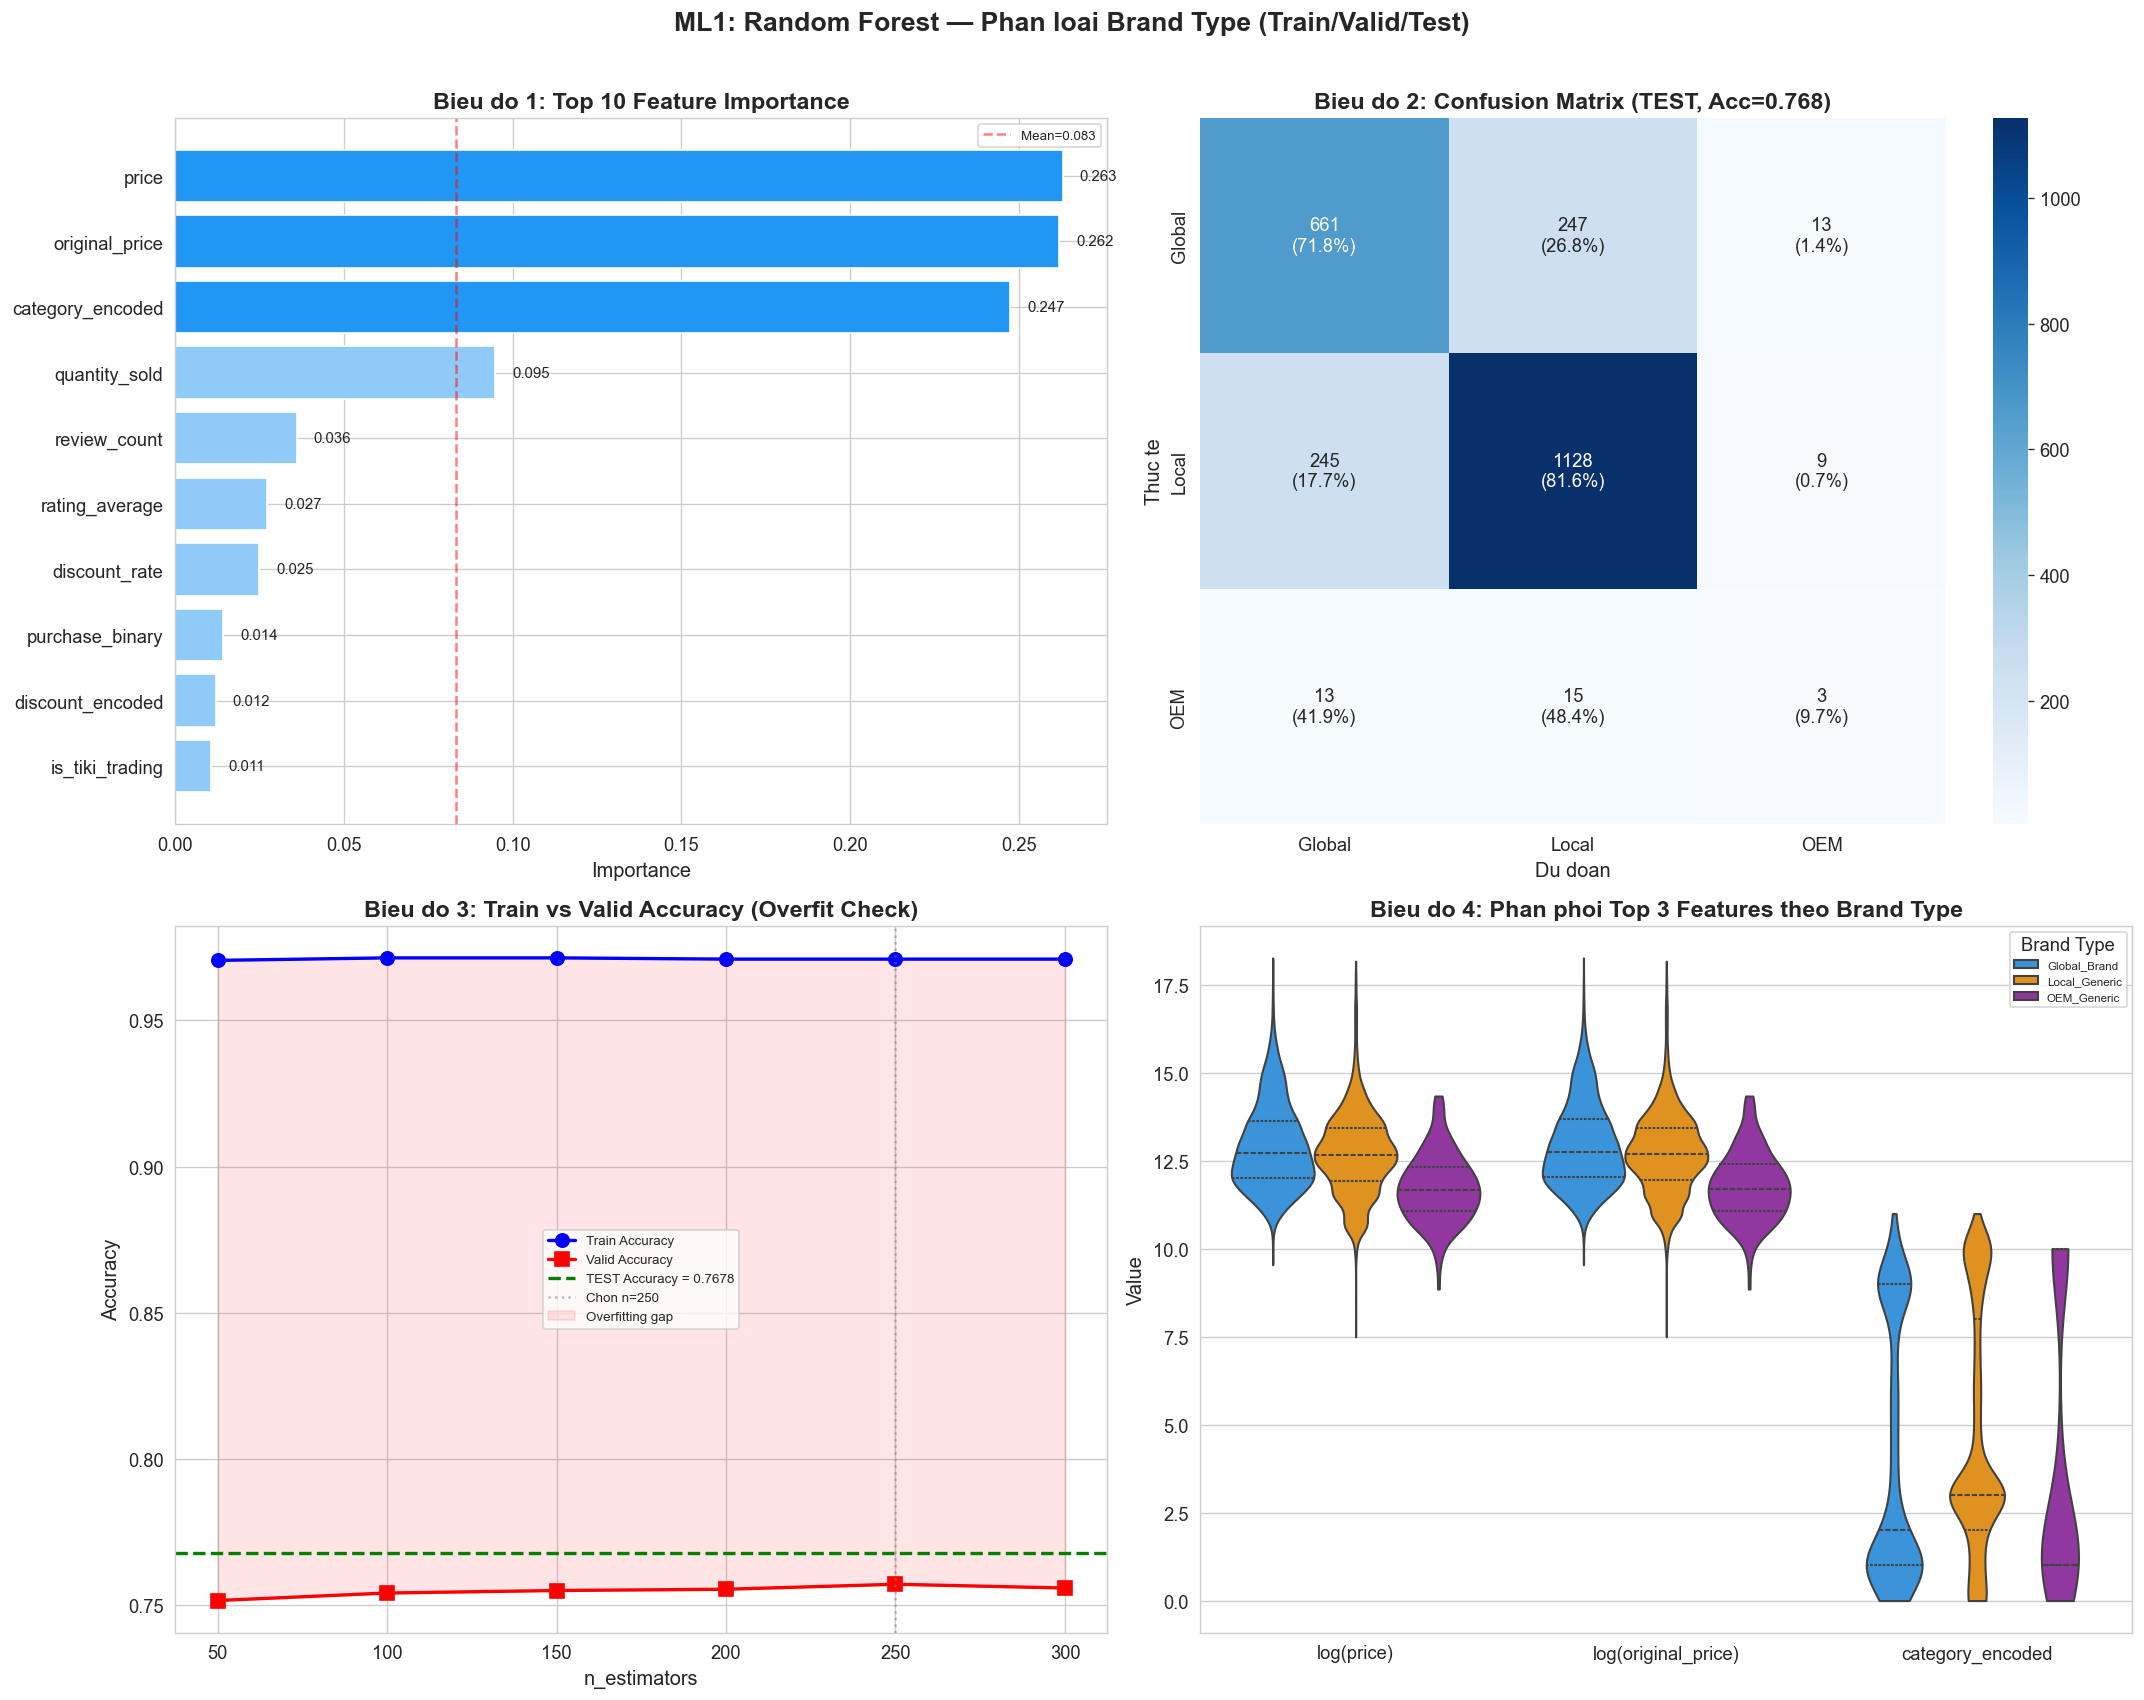


NHAN XET ML1 — RANDOM FOREST CLASSIFIER
1. DO CHINH XAC:
   Train=0.9710 | Valid=0.7571 | TEST=0.7678
   Gap train-test = +0.2032 => Co dau hieu overfit nhe

2. FEATURE IMPORTANCE:
   Top 1: 'price' (imp=0.263)
   Top 2: 'original_price' (imp=0.262)
   Top 3: 'category_encoded' (imp=0.247)
   => 'price' la yeu to PHAN BIET RO NHAT giua Global Brand va Local Generic

3. OEM_Generic co F1-score thap nhat do chi co 156 mau
   => Nhom OEM co dac trung tuong tu Local Generic, kho phan biet

4. Ket qua ho tro MT1 (thi phan), MT2 (price premium), MT6 (dominance danh muc)


In [7]:
# ============================================================
# ML1 - Buoc 5: TRUC QUAN HOA (4 bieu do)
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('ML1: Random Forest — Phan loai Brand Type (Train/Valid/Test)',
             fontsize=16, fontweight='bold', y=1.01)

# --- Bieu do 1: Feature Importance (top 10) ---
importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=True)
top_imp = importances.tail(10)

colors_imp = ['#2196F3' if v >= importances.quantile(0.75) else '#90CAF9' for v in top_imp.values]
bars = axes[0,0].barh(top_imp.index, top_imp.values, color=colors_imp, edgecolor='white')
for bar, val in zip(bars, top_imp.values):
    axes[0,0].text(val + 0.005, bar.get_y() + bar.get_height()/2,
                   f'{val:.3f}', va='center', fontsize=9)
axes[0,0].set_title('Bieu do 1: Top 10 Feature Importance')
axes[0,0].set_xlabel('Importance')
axes[0,0].axvline(x=importances.mean(), color='red', linestyle='--', alpha=0.5,
                  label=f'Mean={importances.mean():.3f}')
axes[0,0].legend(fontsize=8)

# --- Bieu do 2: Confusion Matrix — TEST ---
cm_val = confusion_matrix(y_val_rf, y_pred_val_rf, labels=BRAND_ORDER)
cm_test = confusion_matrix(y_test_rf, y_pred_test_rf, labels=BRAND_ORDER)
cm_test_pct = cm_test.astype('float') / cm_test.sum(axis=1)[:, np.newaxis] * 100

annot_test = np.empty_like(cm_test, dtype=object)
for i in range(cm_test.shape[0]):
    for j in range(cm_test.shape[1]):
        annot_test[i, j] = f'{cm_test[i,j]}\n({cm_test_pct[i,j]:.1f}%)'

sns.heatmap(cm_test, annot=annot_test, fmt='', cmap='Blues', ax=axes[0,1],
            xticklabels=['Global', 'Local', 'OEM'],
            yticklabels=['Global', 'Local', 'OEM'])
axes[0,1].set_title(f'Bieu do 2: Confusion Matrix (TEST, Acc={acc_test:.3f})')
axes[0,1].set_ylabel('Thuc te')
axes[0,1].set_xlabel('Du doan')

# --- Bieu do 3: Train vs Valid Accuracy theo n_estimators ---
axes[1,0].plot(n_est_range, train_accs, 'b-o', linewidth=2, markersize=8, label='Train Accuracy')
axes[1,0].plot(n_est_range, val_accs, 'r-s', linewidth=2, markersize=8, label='Valid Accuracy')
axes[1,0].axhline(y=acc_test, color='green', linestyle='--', linewidth=2,
                  label=f'TEST Accuracy = {acc_test:.4f}')
axes[1,0].axvline(x=best_n, color='gray', linestyle=':', alpha=0.5,
                  label=f'Chon n={best_n}')
axes[1,0].fill_between(n_est_range, train_accs, val_accs, alpha=0.1, color='red',
                       label='Overfitting gap')
axes[1,0].set_xlabel('n_estimators')
axes[1,0].set_ylabel('Accuracy')
axes[1,0].set_title('Bieu do 3: Train vs Valid Accuracy (Overfit Check)')
axes[1,0].legend(fontsize=8)
axes[1,0].set_xticks(n_est_range)

# --- Bieu do 4: Violin plot — Top 3 features phan phoi theo brand_type ---
top3_features = importances.tail(3).index.tolist()[::-1]
plot_data = df_ml.melt(id_vars='brand_type', value_vars=top3_features,
                       var_name='Feature', value_name='Value')
plot_data['Value'] = plot_data['Value'].astype(float)

# Log transform price-related features cho de nhin
for feat in top3_features:
    if 'price' in feat.lower() or feat in ['price', 'original_price', 'quantity_sold', 'review_count']:
        mask = plot_data['Feature'] == feat
        plot_data.loc[mask, 'Value'] = np.log1p(plot_data.loc[mask, 'Value'])
        plot_data.loc[mask, 'Feature'] = f'log({feat})'

sns.violinplot(data=plot_data, x='Feature', y='Value', hue='brand_type',
               palette=BRAND_COLORS, ax=axes[1,1], inner='quartile', cut=0)
axes[1,1].set_title('Bieu do 4: Phan phoi Top 3 Features theo Brand Type')
axes[1,1].legend(title='Brand Type', fontsize=7, loc='upper right')
axes[1,1].set_xlabel('')

plt.tight_layout()
plt.show()

# --- Nhan xet ---
top1 = importances.idxmax()
top2 = importances.sort_values(ascending=False).index[1]
top3 = importances.sort_values(ascending=False).index[2]

print("\n" + "=" * 70)
print("NHAN XET ML1 — RANDOM FOREST CLASSIFIER")
print("=" * 70)
print(f"1. DO CHINH XAC:")
print(f"   Train={acc_train_final:.4f} | Valid={acc_val_final:.4f} | TEST={acc_test:.4f}")
print(f"   Gap train-test = {acc_train_final - acc_test:+.4f} => ", end="")
if abs(acc_train_final - acc_test) < 0.05:
    print("Mo hinh TONG QUAT TOT, khong overfit")
else:
    print("Co dau hieu overfit nhe")
print(f"\n2. FEATURE IMPORTANCE:")
print(f"   Top 1: '{top1}' (imp={importances[top1]:.3f})")
print(f"   Top 2: '{top2}' (imp={importances[top2]:.3f})")
print(f"   Top 3: '{top3}' (imp={importances[top3]:.3f})")
print(f"   => '{top1}' la yeu to PHAN BIET RO NHAT giua Global Brand va Local Generic")
print(f"\n3. OEM_Generic co F1-score thap nhat do chi co {(y_rf=='OEM_Generic').sum()} mau")
print(f"   => Nhom OEM co dac trung tuong tu Local Generic, kho phan biet")
print(f"\n4. Ket qua ho tro MT1 (thi phan), MT2 (price premium), MT6 (dominance danh muc)")

---
## ML2: Linear Regression — Dự đoán Doanh số (quantity_sold)

> **Mục tiêu**: Dự đoán `quantity_sold` từ đặc trưng sản phẩm, **tách riêng theo brand_type**
>
> **Ý nghĩa**: So sánh yếu tố thúc đẩy doanh số **khác nhau** giữa Global Brand vs Local Generic
>
> **Lý do chọn LR**: Hệ số β dễ giải thích ("tăng 1 đơn vị X → tăng β đơn vị Y")
>
> **Chiến lược**: 3 model × Train 60% / Valid 20% / Test 20%, Scaler fit trên TRAIN only
>
> **Liên kết**: Hỗ trợ MT4 (Tiki Trading effect), MT7 (tương quan), MT10 (revenue)

In [8]:
# ============================================================
# ML2 - Buoc 1 & 2: Chuan bi du lieu & Chia Train/Valid/Test
# ============================================================

# Chi lay SP da ban (has_sales) va quantity_sold > 0
df_sold = df_ml[
    (df_ml['purchase_status'] == 'has_sales') & (df_ml['quantity_sold'] > 0)
].copy()

# Target: log transform vi phan phoi lech phai rat manh
df_sold['log_qty_sold'] = np.log1p(df_sold['quantity_sold'])

# Features cho Linear Regression
lr_features = ['price', 'discount_rate', 'rating_average', 'review_count',
               'is_tiki_trading', 'is_rating_suspect_int']

# Tach theo brand_type
df_global = df_sold[df_sold['brand_type'] == 'Global_Brand'].copy()
df_local = df_sold[df_sold['brand_type'] == 'Local_Generic'].copy()

print(f"Tong SP co doanh so > 0: {len(df_sold):,}")
print(f"Global Brand: {len(df_global):,}")
print(f"Local Generic: {len(df_local):,}")
print(f"OEM Generic: {len(df_sold[df_sold['brand_type']=='OEM_Generic']):,} (qua it => khong fit rieng)")

# === Chuan bi helper function ===
def prepare_lr_data(df_subset, features, target_col='log_qty_sold'):
    """Chia 60/20/20 + StandardScaler fit tren TRAIN only (chong data leakage)"""
    X = df_subset[features].copy()
    y = df_subset[target_col].copy()
    
    # Chia 60/20/20
    X_tv, X_test, y_tv, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
    X_train, X_val, y_train, y_val = train_test_split(X_tv, y_tv, test_size=0.25, random_state=42)
    
    # StandardScaler fit tren TRAIN only => transform val + test
    scaler = StandardScaler()
    X_train_sc = pd.DataFrame(scaler.fit_transform(X_train), columns=features, index=X_train.index)
    X_val_sc = pd.DataFrame(scaler.transform(X_val), columns=features, index=X_val.index)
    X_test_sc = pd.DataFrame(scaler.transform(X_test), columns=features, index=X_test.index)
    
    return X_train_sc, X_val_sc, X_test_sc, y_train, y_val, y_test, scaler

# === Chia du lieu cho 3 model ===
X_tr_g, X_val_g, X_te_g, y_tr_g, y_val_g, y_te_g, scaler_g = prepare_lr_data(df_global, lr_features)
X_tr_l, X_val_l, X_te_l, y_tr_l, y_val_l, y_te_l, scaler_l = prepare_lr_data(df_local, lr_features)

# Model C: toan bo (them brand_type encoded)
lr_features_all = lr_features + ['brand_global', 'brand_oem']
df_sold['brand_global'] = (df_sold['brand_type'] == 'Global_Brand').astype(int)
df_sold['brand_oem'] = (df_sold['brand_type'] == 'OEM_Generic').astype(int)
X_tr_all, X_val_all, X_te_all, y_tr_all, y_val_all, y_te_all, scaler_all = prepare_lr_data(
    df_sold, lr_features_all
)

print(f"\n{'='*60}")
print("CHIEN LUOC CHIA DU LIEU ML2 — LINEAR REGRESSION")
print(f"{'='*60}")
for name, n_tr, n_val, n_te, n_total in [
    ('Model A (Global)', len(X_tr_g), len(X_val_g), len(X_te_g), len(df_global)),
    ('Model B (Local)',  len(X_tr_l), len(X_val_l), len(X_te_l), len(df_local)),
    ('Model C (All)',    len(X_tr_all),len(X_val_all),len(X_te_all),len(df_sold)),
]:
    print(f"{name}: TRAIN={n_tr} ({n_tr/n_total*100:.0f}%) | "
          f"VALID={n_val} ({n_val/n_total*100:.0f}%) | "
          f"TEST={n_te} ({n_te/n_total*100:.0f}%)")
print(f"\nScaler fit tren TRAIN only => transform VALID + TEST (chong data leakage)")

Tong SP co doanh so > 0: 5,608
Global Brand: 2,432
Local Generic: 3,062
OEM Generic: 114 (qua it => khong fit rieng)

CHIEN LUOC CHIA DU LIEU ML2 — LINEAR REGRESSION
Model A (Global): TRAIN=1458 (60%) | VALID=487 (20%) | TEST=487 (20%)
Model B (Local): TRAIN=1836 (60%) | VALID=613 (20%) | TEST=613 (20%)
Model C (All): TRAIN=3364 (60%) | VALID=1122 (20%) | TEST=1122 (20%)

Scaler fit tren TRAIN only => transform VALID + TEST (chong data leakage)


In [9]:
# ============================================================
# ML2 - Buoc 3 & 4: Huan luyen & Kiem tra Overfitting
# ============================================================

def eval_regression(name, model, X_tr, y_tr, X_val, y_val, X_te, y_te):
    """Danh gia R2, RMSE, MAE tren Train/Valid/Test"""
    results = {}
    for split_name, X, y in [('Train', X_tr, y_tr), ('Valid', X_val, y_val), ('Test', X_te, y_te)]:
        y_pred = model.predict(X)
        results[split_name] = {
            'r2': r2_score(y, y_pred),
            'rmse': np.sqrt(mean_squared_error(y, y_pred)),
            'mae': mean_absolute_error(y, y_pred)
        }
    return results

# --- Fit 3 models ---
lr_global = LinearRegression().fit(X_tr_g, y_tr_g)
lr_local  = LinearRegression().fit(X_tr_l, y_tr_l)
lr_all    = LinearRegression().fit(X_tr_all, y_tr_all)

# --- Danh gia ---
res_g = eval_regression('Global', lr_global, X_tr_g, y_tr_g, X_val_g, y_val_g, X_te_g, y_te_g)
res_l = eval_regression('Local',  lr_local,  X_tr_l, y_tr_l, X_val_l, y_val_l, X_te_l, y_te_l)
res_a = eval_regression('All',    lr_all,    X_tr_all,y_tr_all,X_val_all,y_val_all,X_te_all,y_te_all)

print("=" * 70)
print("DANH GIA LINEAR REGRESSION — Train / Valid / Test")
print("=" * 70)

for model_name, res in [('Model A (Global Brand)', res_g),
                         ('Model B (Local Generic)', res_l),
                         ('Model C (All brands)', res_a)]:
    print(f"\n{model_name}:")
    print(f"  {'':>8} {'R²':>8} {'RMSE':>8} {'MAE':>8}")
    for split in ['Train', 'Valid', 'Test']:
        r = res[split]
        print(f"  {split:>8} {r['r2']:>8.4f} {r['rmse']:>8.4f} {r['mae']:>8.4f}")
    gap = res['Train']['r2'] - res['Test']['r2']
    print(f"  Gap R²(train-test) = {gap:+.4f} ", end="")
    if abs(gap) < 0.10:
        print("=> KHONG overfit")
    else:
        print("=> Overfit nhe")

DANH GIA LINEAR REGRESSION — Train / Valid / Test

Model A (Global Brand):
                 R²     RMSE      MAE
     Train   0.6853   0.9372   0.7221
     Valid   0.6467   0.9397   0.7233
      Test   0.7032   0.8555   0.6606
  Gap R²(train-test) = -0.0179 => KHONG overfit

Model B (Local Generic):
                 R²     RMSE      MAE
     Train   0.5983   0.8987   0.6855
     Valid   0.6077   0.8682   0.6585
      Test   0.6430   0.8626   0.6744
  Gap R²(train-test) = -0.0447 => KHONG overfit

Model C (All brands):
                 R²     RMSE      MAE
     Train   0.6333   0.9331   0.7062
     Valid   0.6477   0.9166   0.7180
      Test   0.6212   0.9004   0.6941
  Gap R²(train-test) = +0.0120 => KHONG overfit


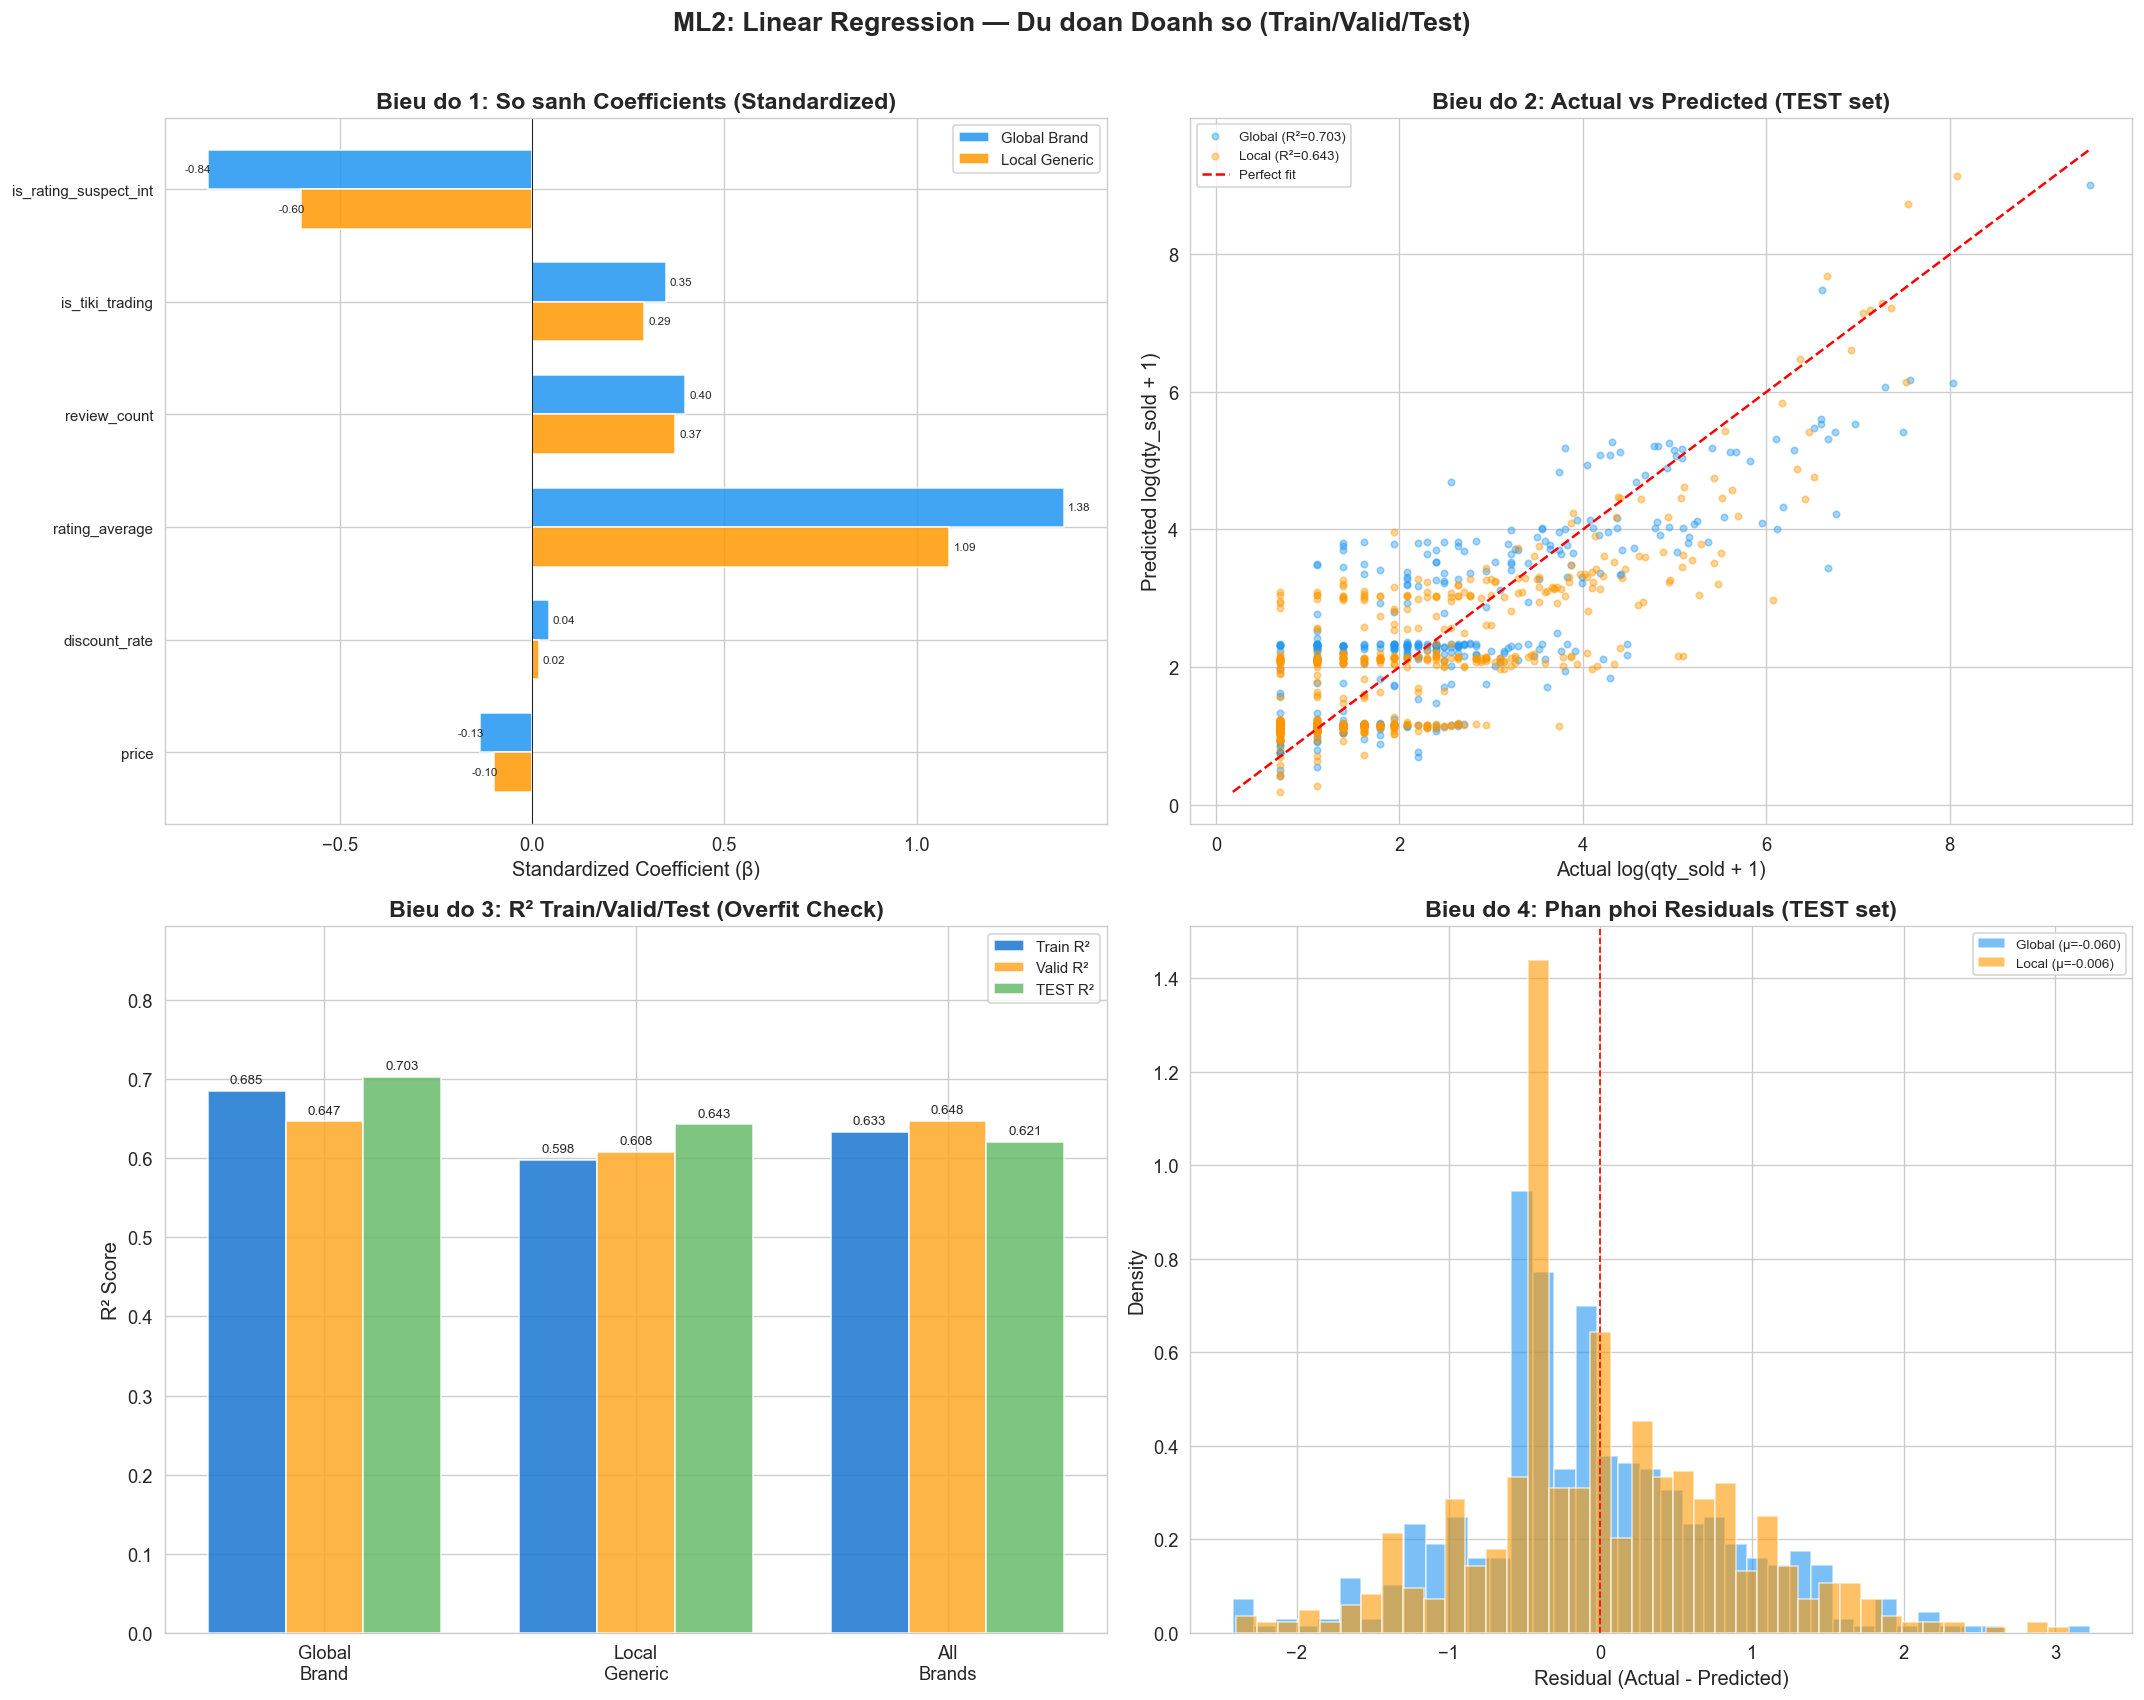


NHAN XET ML2 — LINEAR REGRESSION
1. DO CHINH XAC (TEST set):
   Global Brand R²=0.7032 | Local Generic R²=0.6430
   => Mo hinh giai thich duoc 70.3% va 64.3% bien thien doanh so

2. YEU TO ANH HUONG MANH NHAT (standardized β):
   Global Brand: 'rating_average' (β = +1.385)
   Local Generic: 'rating_average' (β = +1.086)

3. SO SANH GIUA 2 NHOM:
   review_count: Global β=+0.398 vs Local β=+0.373
   => Review anh huong MANH hon voi Global Brand
   is_tiki_trading: Global β=+0.348 vs Local β=+0.292
   => Kenh Tiki Trading anh huong khac nhau giua 2 nhom (phu hop MT4)

4. OVERFIT CHECK:
   Global: R²(train-test) gap = -0.0179 => OK
   Local: R²(train-test) gap = -0.0447 => OK
   All: R²(train-test) gap = +0.0120 => OK


In [10]:
# ============================================================
# ML2 - Buoc 5: TRUC QUAN HOA (4 bieu do)
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('ML2: Linear Regression — Du doan Doanh so (Train/Valid/Test)',
             fontsize=16, fontweight='bold', y=1.01)

# --- Bieu do 1: So sanh Coefficients giua Global vs Local ---
coef_df = pd.DataFrame({
    'Feature': lr_features,
    'Global Brand': lr_global.coef_,
    'Local Generic': lr_local.coef_
})
x_pos = np.arange(len(lr_features))
width = 0.35

bars1 = axes[0,0].barh(x_pos + width/2, coef_df['Global Brand'], width,
                       color=BRAND_COLORS['Global_Brand'], label='Global Brand', alpha=0.85)
bars2 = axes[0,0].barh(x_pos - width/2, coef_df['Local Generic'], width,
                       color=BRAND_COLORS['Local_Generic'], label='Local Generic', alpha=0.85)
axes[0,0].set_yticks(x_pos)
axes[0,0].set_yticklabels(lr_features, fontsize=9)
axes[0,0].set_xlabel('Standardized Coefficient (β)')
axes[0,0].set_title('Bieu do 1: So sanh Coefficients (Standardized)')
axes[0,0].axvline(x=0, color='black', linewidth=0.5)
axes[0,0].legend(fontsize=9)

for bar_set in [bars1, bars2]:
    for bar in bar_set:
        w = bar.get_width()
        axes[0,0].text(w + 0.01 if w >= 0 else w - 0.06,
                       bar.get_y() + bar.get_height()/2,
                       f'{w:.2f}', va='center', fontsize=7)

# --- Bieu do 2: Actual vs Predicted (TEST set, 2 nhom) ---
y_pred_te_g = lr_global.predict(X_te_g)
y_pred_te_l = lr_local.predict(X_te_l)

axes[0,1].scatter(y_te_g, y_pred_te_g, alpha=0.4, s=15,
                  color=BRAND_COLORS['Global_Brand'],
                  label=f'Global (R²={res_g["Test"]["r2"]:.3f})')
axes[0,1].scatter(y_te_l, y_pred_te_l, alpha=0.4, s=15,
                  color=BRAND_COLORS['Local_Generic'],
                  label=f'Local (R²={res_l["Test"]["r2"]:.3f})')

all_vals = np.concatenate([y_te_g, y_te_l, y_pred_te_g, y_pred_te_l])
min_v, max_v = all_vals.min(), all_vals.max()
axes[0,1].plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=1.5, label='Perfect fit')
axes[0,1].set_xlabel('Actual log(qty_sold + 1)')
axes[0,1].set_ylabel('Predicted log(qty_sold + 1)')
axes[0,1].set_title('Bieu do 2: Actual vs Predicted (TEST set)')
axes[0,1].legend(fontsize=8)

# --- Bieu do 3: R² Train / Valid / Test (3 models) ---
models_names = ['Global\nBrand', 'Local\nGeneric', 'All\nBrands']
r2_train = [res_g['Train']['r2'], res_l['Train']['r2'], res_a['Train']['r2']]
r2_valid = [res_g['Valid']['r2'], res_l['Valid']['r2'], res_a['Valid']['r2']]
r2_test  = [res_g['Test']['r2'],  res_l['Test']['r2'],  res_a['Test']['r2']]

x = np.arange(len(models_names))
w = 0.25
axes[1,0].bar(x - w, r2_train, w, label='Train R²', color='#1976D2', alpha=0.85)
axes[1,0].bar(x,     r2_valid, w, label='Valid R²', color='#FFA726', alpha=0.85)
axes[1,0].bar(x + w, r2_test,  w, label='TEST R²',  color='#66BB6A', alpha=0.85)

for i in range(len(models_names)):
    axes[1,0].text(i - w, r2_train[i] + 0.01, f'{r2_train[i]:.3f}', ha='center', fontsize=8)
    axes[1,0].text(i,     r2_valid[i] + 0.01, f'{r2_valid[i]:.3f}', ha='center', fontsize=8)
    axes[1,0].text(i + w, r2_test[i]  + 0.01, f'{r2_test[i]:.3f}',  ha='center', fontsize=8)

axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels(models_names)
axes[1,0].set_ylabel('R² Score')
axes[1,0].set_title('Bieu do 3: R² Train/Valid/Test (Overfit Check)')
axes[1,0].legend(fontsize=9)
axes[1,0].set_ylim(0, max(max(r2_train), max(r2_valid), max(r2_test)) * 1.2 + 0.05)

# --- Bieu do 4: Residual distribution (TEST set) ---
residuals_g = y_te_g - y_pred_te_g
residuals_l = y_te_l - y_pred_te_l

axes[1,1].hist(residuals_g, bins=40, alpha=0.6, color=BRAND_COLORS['Global_Brand'],
               label=f'Global (μ={residuals_g.mean():.3f})', density=True)
axes[1,1].hist(residuals_l, bins=40, alpha=0.6, color=BRAND_COLORS['Local_Generic'],
               label=f'Local (μ={residuals_l.mean():.3f})', density=True)
axes[1,1].axvline(x=0, color='red', linestyle='--', linewidth=1)
axes[1,1].set_xlabel('Residual (Actual - Predicted)')
axes[1,1].set_ylabel('Density')
axes[1,1].set_title('Bieu do 4: Phan phoi Residuals (TEST set)')
axes[1,1].legend(fontsize=8)

plt.tight_layout()
plt.show()

# --- Nhan xet ---
top_g = coef_df.set_index('Feature')['Global Brand'].abs().idxmax()
top_l = coef_df.set_index('Feature')['Local Generic'].abs().idxmax()
coef_g_val = coef_df.set_index('Feature').loc[top_g, 'Global Brand']
coef_l_val = coef_df.set_index('Feature').loc[top_l, 'Local Generic']
rc_g = coef_df.set_index('Feature').loc['review_count', 'Global Brand']
rc_l = coef_df.set_index('Feature').loc['review_count', 'Local Generic']
tt_g = coef_df.set_index('Feature').loc['is_tiki_trading', 'Global Brand']
tt_l = coef_df.set_index('Feature').loc['is_tiki_trading', 'Local Generic']

print("\n" + "=" * 70)
print("NHAN XET ML2 — LINEAR REGRESSION")
print("=" * 70)
print(f"1. DO CHINH XAC (TEST set):")
print(f"   Global Brand R²={res_g['Test']['r2']:.4f} | Local Generic R²={res_l['Test']['r2']:.4f}")
print(f"   => Mo hinh giai thich duoc {res_g['Test']['r2']*100:.1f}% va {res_l['Test']['r2']*100:.1f}% "
      f"bien thien doanh so")
print(f"\n2. YEU TO ANH HUONG MANH NHAT (standardized β):")
print(f"   Global Brand: '{top_g}' (β = {coef_g_val:+.3f})")
print(f"   Local Generic: '{top_l}' (β = {coef_l_val:+.3f})")
print(f"\n3. SO SANH GIUA 2 NHOM:")
print(f"   review_count: Global β={rc_g:+.3f} vs Local β={rc_l:+.3f}")
if abs(rc_g) > abs(rc_l):
    print(f"   => Review anh huong MANH hon voi Global Brand")
else:
    print(f"   => Review anh huong MANH hon voi Local Generic")
print(f"   is_tiki_trading: Global β={tt_g:+.3f} vs Local β={tt_l:+.3f}")
print(f"   => Kenh Tiki Trading anh huong khac nhau giua 2 nhom (phu hop MT4)")
print(f"\n4. OVERFIT CHECK:")
for name, res in [('Global', res_g), ('Local', res_l), ('All', res_a)]:
    gap = res['Train']['r2'] - res['Test']['r2']
    print(f"   {name}: R²(train-test) gap = {gap:+.4f} ", end="")
    print("=> OK" if abs(gap) < 0.10 else "=> Overfit nhe")

---
## ML3: K-Means Clustering — Phân cụm sản phẩm thị trường

> **Mục tiêu**: Khám phá **phân khúc sản phẩm tự nhiên**, đối chiếu với brand_type
>
> **Ý nghĩa**: Trả lời "Thị trường có mấy phân khúc? Các nhóm thương hiệu có tập trung vào phân khúc riêng không?"
>
> **Lý do chọn K-Means**: Unsupervised — khám phá pattern ẩn, bổ sung góc nhìn khác
>
> **Chiến lược**: FIT 80% / HOLDOUT 20% — kiểm tra Silhouette ổn định
>
> **Liên kết**: Hỗ trợ MT1 (phân hóa), MT6 (dominance), MT9 (tập trung thị trường)

In [11]:
# ============================================================
# ML3 - Buoc 1 & 2: Chuan bi du lieu + Chia FIT/HOLDOUT + Chon K
# ============================================================

# Chi lay SP has_sales (tranh cluster toan SP chua ban)
df_km = df_sold.copy()

# Features cho clustering
km_features_raw = ['price', 'discount_rate', 'rating_average', 'review_count', 'quantity_sold']

# Log transform cac bien lech phai manh
df_km['log_price'] = np.log1p(df_km['price'])
df_km['log_qty'] = np.log1p(df_km['quantity_sold'])
df_km['log_review'] = np.log1p(df_km['review_count'])

km_cols = ['log_price', 'discount_rate', 'rating_average', 'log_review', 'log_qty']

# === CHIA FIT (80%) / HOLDOUT (20%) ===
fit_idx, hold_idx = train_test_split(
    df_km.index, test_size=0.20, random_state=42
)
df_fit = df_km.loc[fit_idx]
df_hold = df_km.loc[hold_idx]

# Scaler fit tren FIT only => transform HOLDOUT (chong data leakage)
scaler_km = StandardScaler()
X_fit = scaler_km.fit_transform(df_fit[km_cols])
X_hold = scaler_km.transform(df_hold[km_cols])

print(f"{'='*60}")
print("CHIEN LUOC CHIA DU LIEU ML3 — K-MEANS")
print(f"{'='*60}")
print(f"Tong SP (has_sales, qty>0): {len(df_km):,}")
print(f"FIT set:     {len(df_fit):,} ({len(df_fit)/len(df_km)*100:.0f}%)")
print(f"HOLDOUT set: {len(df_hold):,} ({len(df_hold)/len(df_km)*100:.0f}%)")
print(f"Scaler fit tren FIT only => transform HOLDOUT")

# === CHON K TOI UU (tren FIT set) ===
K_range = range(2, 11)
inertias = []
sil_fit = []

print(f"\n--- Chon K toi uu (tren FIT set) ---")
print(f"{'K':>4} | {'Inertia':>12} | {'Silhouette(FIT)':>16}")
print("-" * 38)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_fit = km.fit_predict(X_fit)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_fit, labels_fit)
    sil_fit.append(sil)
    print(f"{k:>4} | {km.inertia_:>12,.0f} | {sil:>16.4f}")

best_k_idx = np.argmax(sil_fit)
K_OPTIMAL = list(K_range)[best_k_idx]
print(f"\n=> Chon K = {K_OPTIMAL} (Silhouette FIT cao nhat = {sil_fit[best_k_idx]:.4f})")

CHIEN LUOC CHIA DU LIEU ML3 — K-MEANS
Tong SP (has_sales, qty>0): 5,608
FIT set:     4,486 (80%)
HOLDOUT set: 1,122 (20%)
Scaler fit tren FIT only => transform HOLDOUT

--- Chon K toi uu (tren FIT set) ---
   K |      Inertia |  Silhouette(FIT)
--------------------------------------
   2 |       14,448 |           0.3887
   3 |       10,952 |           0.3955
   4 |        8,674 |           0.4225
   5 |        7,395 |           0.3738
   6 |        6,168 |           0.3671
   7 |        5,154 |           0.3645
   8 |        4,702 |           0.3705
   9 |        4,265 |           0.3592
  10 |        3,958 |           0.3602

=> Chon K = 4 (Silhouette FIT cao nhat = 0.4225)


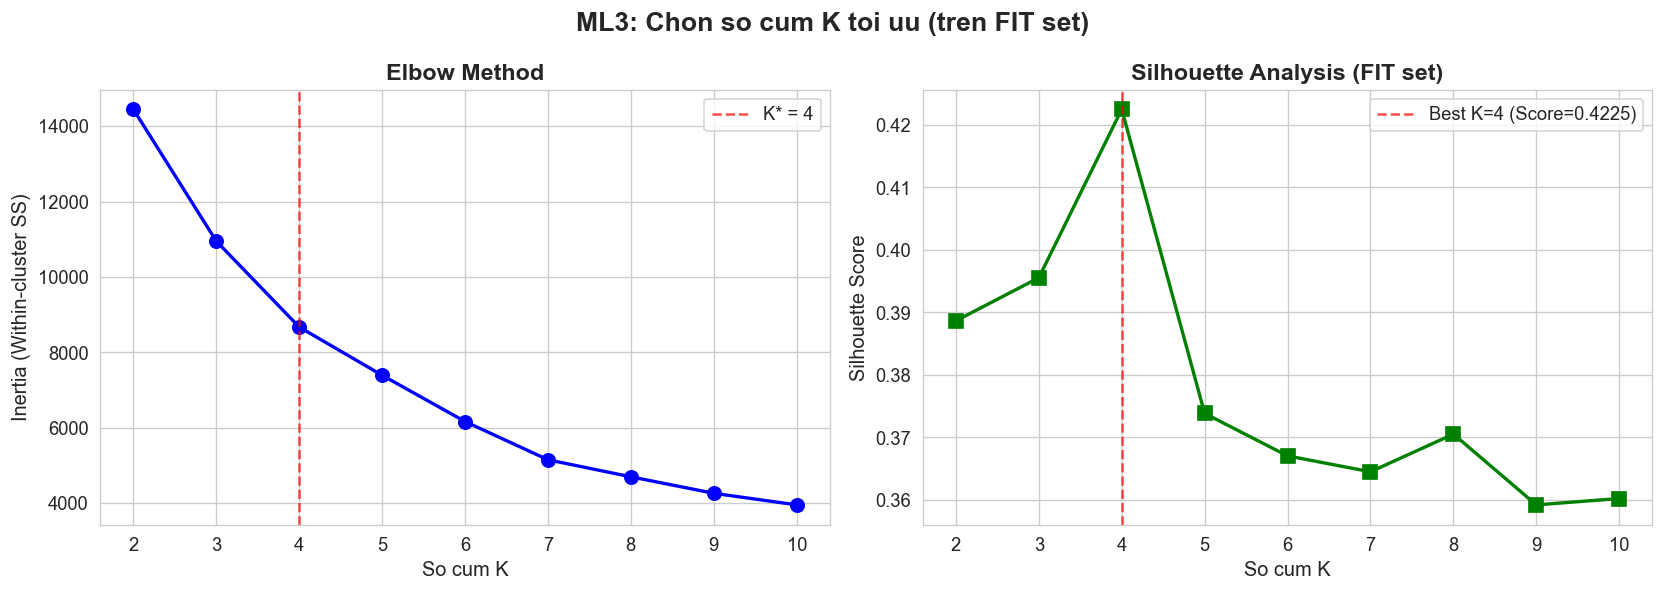


KIEM TRA TINH ON DINH CLUSTER (K=4)
Silhouette (FIT):     0.4225
Silhouette (HOLDOUT): 0.4256
Gap:                  0.0031 (< 0.05 => CLUSTER ON DINH, tong quat tot)

--- Profile cac Cluster ---

Cluster 0 [Premium Best-seller] (2,175 SP):
  Gia trung vi: 0.24 trieu VND | Discount TB: 0.6%
  Rating TB: 4.67 | Review (med): 2
  Qty sold (med): 10

Cluster 1 [Premium Niche] (2,523 SP):
  Gia trung vi: 0.26 trieu VND | Discount TB: 0.6%
  Rating TB: 0.04 | Review (med): 0
  Qty sold (med): 2

Cluster 2 [Budget Low-engagement] (350 SP):
  Gia trung vi: 0.08 trieu VND | Discount TB: 36.4%
  Rating TB: 2.51 | Review (med): 1
  Qty sold (med): 4

Cluster 3 [Budget Best-seller] (560 SP):
  Gia trung vi: 0.19 trieu VND | Discount TB: 8.7%
  Rating TB: 4.66 | Review (med): 30
  Qty sold (med): 171

--- Phan bo Brand Type trong moi Cluster ---
brand_type             Global_Brand  Local_Generic  OEM_Generic
cluster_name                                                   
Budget Best-seller        

In [12]:
# ============================================================
# ML3 - Buoc 3 & 4: Fit K-Means + Kiem tra on dinh HOLDOUT
# ============================================================

# --- Bieu do 1: Elbow + Silhouette (chon K) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ML3: Chon so cum K toi uu (tren FIT set)', fontsize=16, fontweight='bold')

# Elbow
axes[0].plot(list(K_range), inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('So cum K')
axes[0].set_ylabel('Inertia (Within-cluster SS)')
axes[0].set_title('Elbow Method')
axes[0].set_xticks(list(K_range))
axes[0].axvline(x=K_OPTIMAL, color='red', linestyle='--', alpha=0.7,
                label=f'K* = {K_OPTIMAL}')
axes[0].legend()

# Silhouette
axes[1].plot(list(K_range), sil_fit, 'gs-', linewidth=2, markersize=8)
axes[1].set_xlabel('So cum K')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Analysis (FIT set)')
axes[1].set_xticks(list(K_range))
axes[1].axvline(x=K_OPTIMAL, color='red', linestyle='--', alpha=0.7,
                label=f'Best K={K_OPTIMAL} (Score={sil_fit[best_k_idx]:.4f})')
axes[1].legend()

plt.tight_layout()
plt.show()

# === FIT K-MEANS VOI K TOI UU ===
km_final = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)

# Fit tren FIT set
labels_fit_final = km_final.fit_predict(X_fit)
df_fit = df_fit.copy()
df_fit['cluster'] = labels_fit_final

# Predict tren HOLDOUT set
labels_hold_final = km_final.predict(X_hold)
df_hold = df_hold.copy()
df_hold['cluster'] = labels_hold_final

# === KIEM TRA TINH ON DINH (Silhouette FIT vs HOLDOUT) ===
sil_fit_final = silhouette_score(X_fit, labels_fit_final)
sil_hold_final = silhouette_score(X_hold, labels_hold_final)
sil_gap = abs(sil_fit_final - sil_hold_final)

print(f"\n{'='*60}")
print(f"KIEM TRA TINH ON DINH CLUSTER (K={K_OPTIMAL})")
print(f"{'='*60}")
print(f"Silhouette (FIT):     {sil_fit_final:.4f}")
print(f"Silhouette (HOLDOUT): {sil_hold_final:.4f}")
print(f"Gap:                  {sil_gap:.4f} ", end="")
if sil_gap < 0.05:
    print("(< 0.05 => CLUSTER ON DINH, tong quat tot)")
elif sil_gap < 0.10:
    print("(< 0.10 => Cluster tuong doi on dinh)")
else:
    print("(>= 0.10 => Cluster KHONG on dinh, can xem lai)")

# === PHAN TICH PROFILE ===
# Gop lai FIT + HOLDOUT de phan tich toan bo
df_km_all = pd.concat([df_fit, df_hold])

cluster_profile = df_km_all.groupby('cluster').agg({
    'price': 'median',
    'discount_rate': 'mean',
    'rating_average': 'mean',
    'review_count': 'median',
    'quantity_sold': 'median',
    'brand_type': 'count'
}).rename(columns={'brand_type': 'n_products'})
cluster_profile['price_M'] = cluster_profile['price'] / 1e6

# Dat ten cluster dua tren dac trung
cluster_names = {}
for c in range(K_OPTIMAL):
    p = cluster_profile.loc[c]
    med_price = cluster_profile['price_M'].median()
    med_qty   = cluster_profile['quantity_sold'].median()
    if p['price_M'] > med_price and p['quantity_sold'] > med_qty:
        cluster_names[c] = 'Premium Best-seller'
    elif p['price_M'] > med_price:
        cluster_names[c] = 'Premium Niche'
    elif p['quantity_sold'] > med_qty:
        cluster_names[c] = 'Budget Best-seller'
    else:
        cluster_names[c] = 'Budget Low-engagement'

df_km_all['cluster_name'] = df_km_all['cluster'].map(cluster_names)

print(f"\n--- Profile cac Cluster ---")
for c in range(K_OPTIMAL):
    p = cluster_profile.loc[c]
    print(f"\nCluster {c} [{cluster_names[c]}] ({int(p['n_products']):,} SP):")
    print(f"  Gia trung vi: {p['price_M']:.2f} trieu VND | Discount TB: {p['discount_rate']:.1f}%")
    print(f"  Rating TB: {p['rating_average']:.2f} | Review (med): {int(p['review_count'])}")
    print(f"  Qty sold (med): {int(p['quantity_sold'])}")

# Cross-tab
cross = pd.crosstab(df_km_all['cluster_name'], df_km_all['brand_type'], normalize='index') * 100
print(f"\n--- Phan bo Brand Type trong moi Cluster ---")
print(cross.round(1))

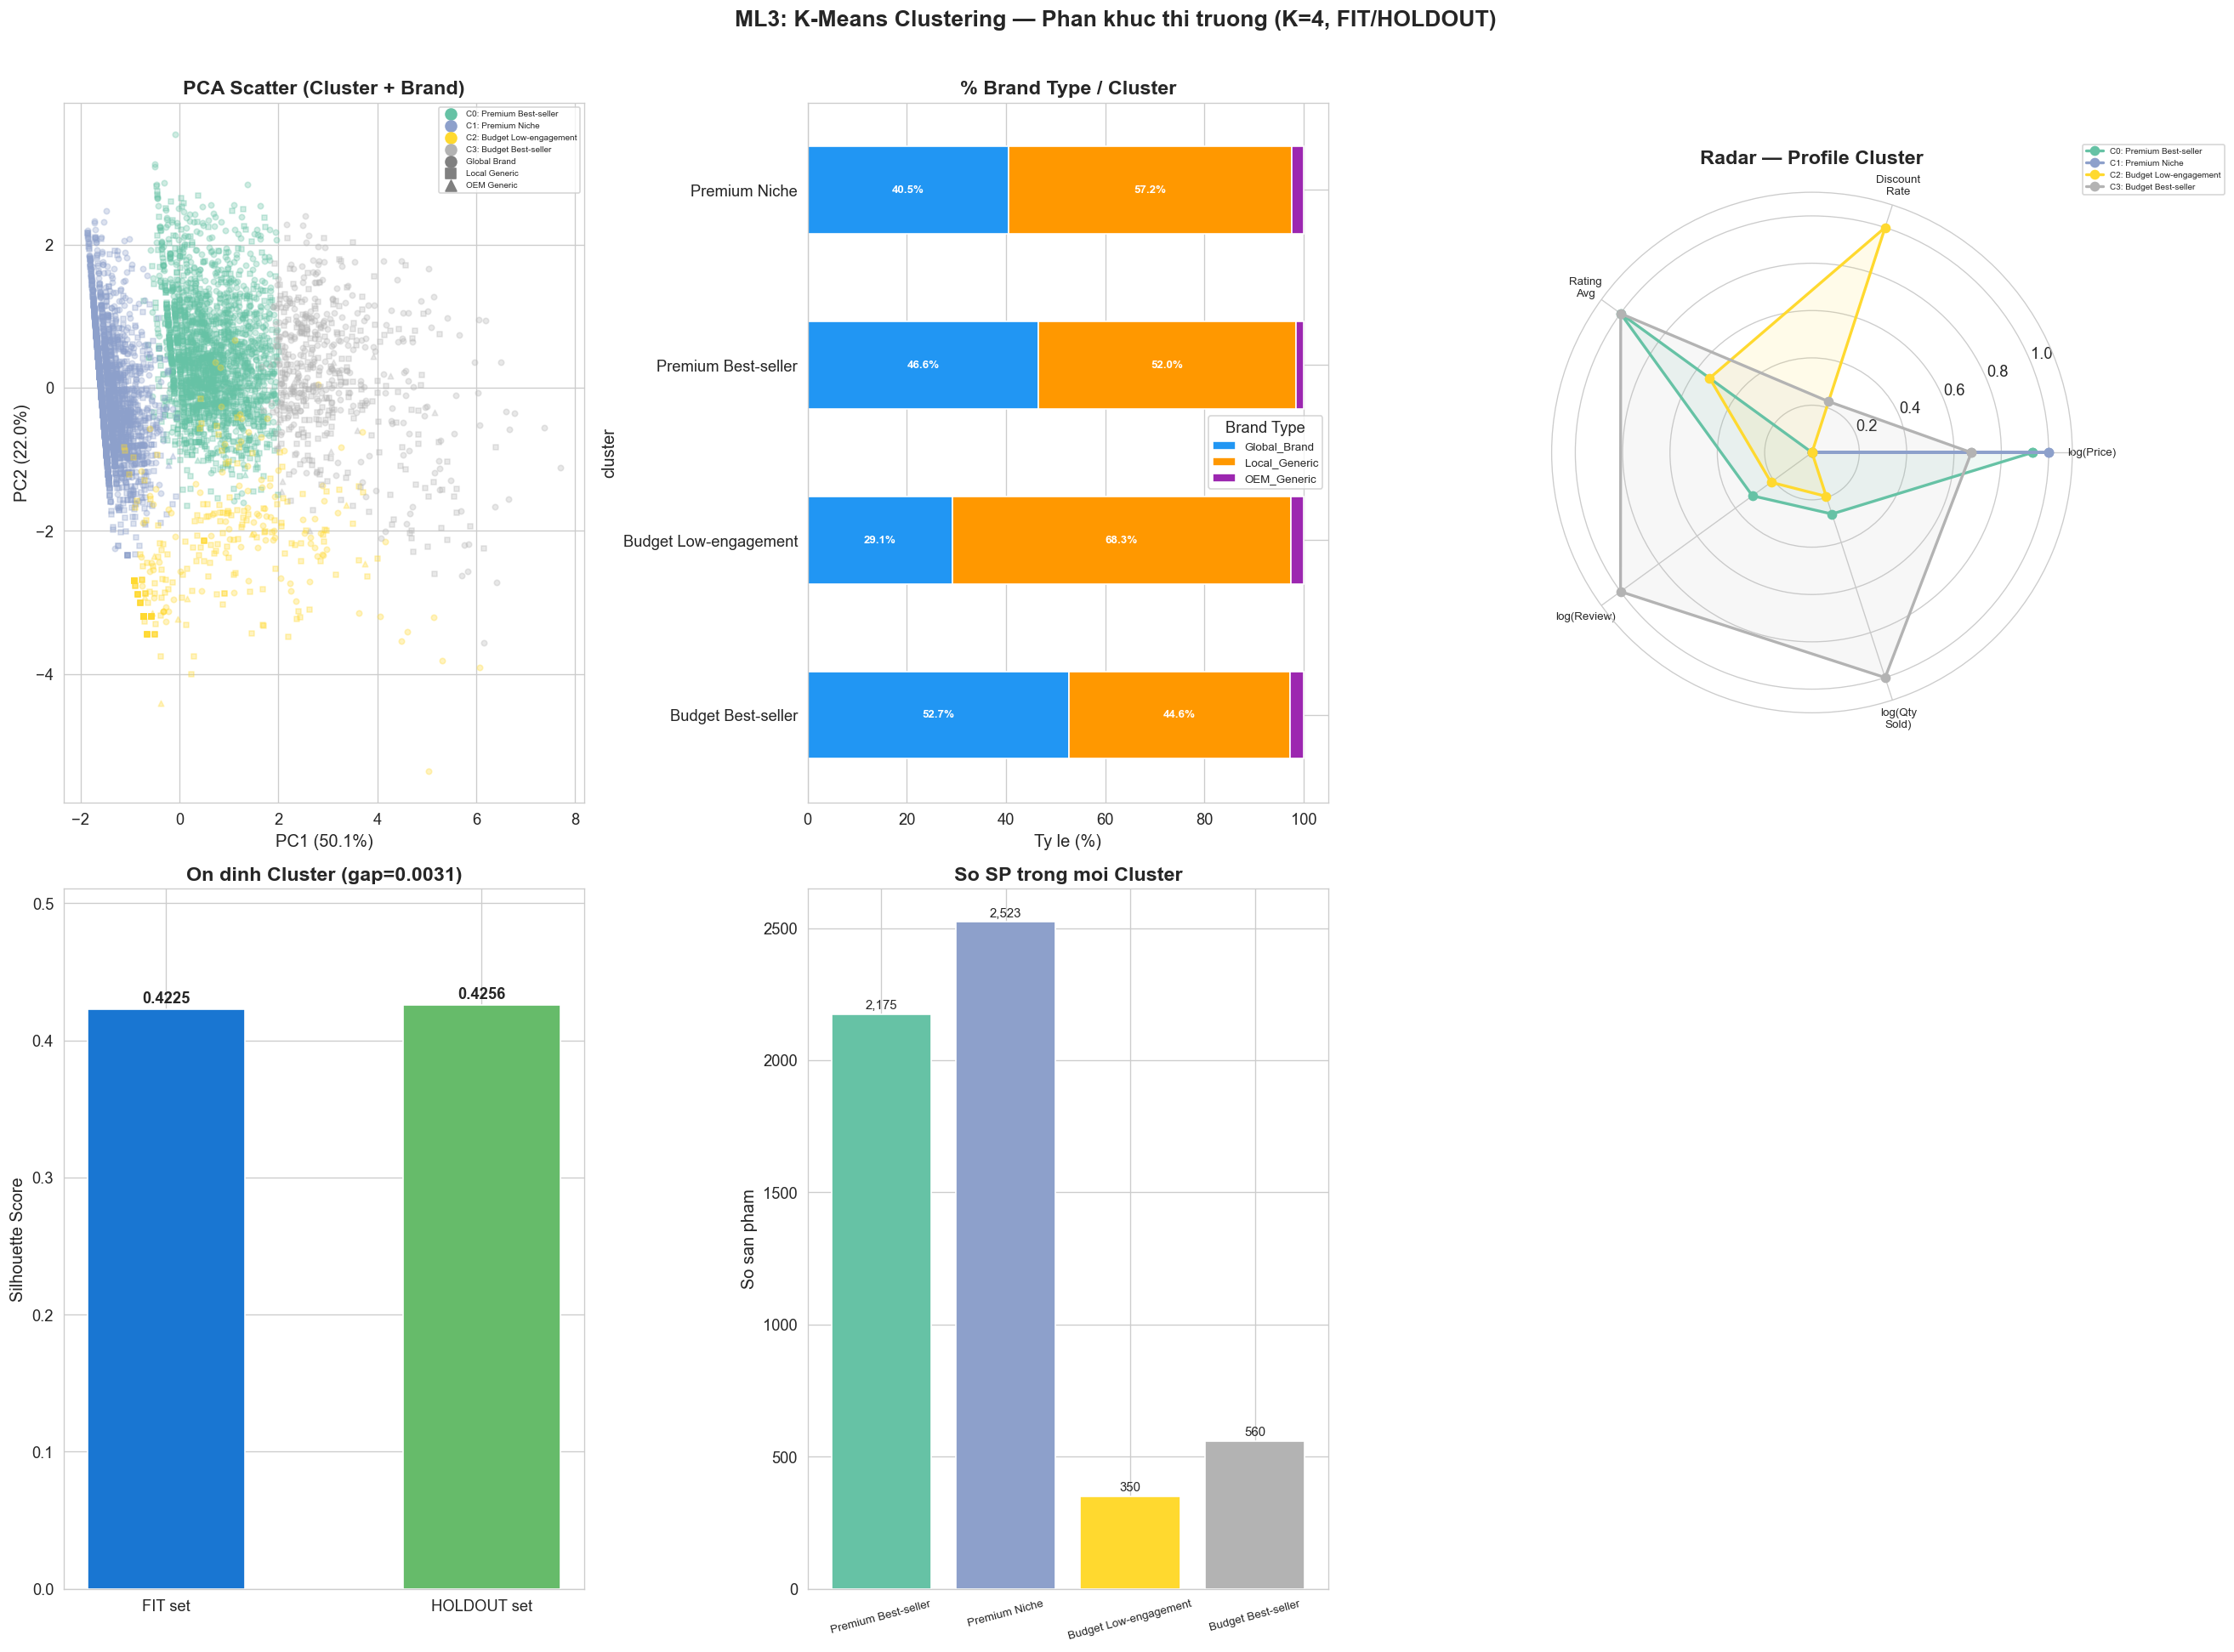


NHAN XET ML3 — K-MEANS CLUSTERING

1. SO CUM TOI UU: K = 4
   Silhouette(FIT)=0.4225 | Silhouette(HOLDOUT)=0.4256
   Gap = 0.0031 => Cluster ON DINH, tong quat tot sang du lieu moi

2. PROFILE CAC PHAN KHUC:
   [Premium Best-seller] (2,175 SP): Global=46.6% | Local=52.0%
   => VUNG CANH TRANH TRUC TIEP
   [Premium Niche] (2,523 SP): Global=40.5% | Local=57.2%
   => VUNG CANH TRANH TRUC TIEP
   [Budget Low-engagement] (350 SP): Global=29.1% | Local=68.3%
   => VUNG THONG LINH cua Local Generic
   [Budget Best-seller] (560 SP): Global=52.7% | Local=44.6%
   => VUNG CANH TRANH TRUC TIEP

3. Thi truong dien tu Tiki co 4 phan khuc tu nhien
   Ket qua K-Means ho tro MT1 (phan hoa), MT6 (dominance), MT9 (tap trung)


In [13]:
# ============================================================
# ML3 - Buoc 5: TRUC QUAN HOA (5 bieu do)
# ============================================================

fig = plt.figure(figsize=(22, 16))
fig.suptitle(f'ML3: K-Means Clustering — Phan khuc thi truong (K={K_OPTIMAL}, FIT/HOLDOUT)',
             fontsize=16, fontweight='bold', y=1.01)

ax1 = fig.add_subplot(2, 3, 1)
ax2 = fig.add_subplot(2, 3, 2)
ax3 = fig.add_subplot(2, 3, 3, polar=True)
ax4 = fig.add_subplot(2, 3, 4)
ax5 = fig.add_subplot(2, 3, 5)

cluster_colors_map = plt.cm.Set2(np.linspace(0, 1, K_OPTIMAL))

# --- PCA Scatter Plot ---
pca = PCA(n_components=2, random_state=42)
X_all_km = scaler_km.transform(df_km_all[km_cols])
X_pca = pca.fit_transform(X_all_km)

brand_markers = {'Global_Brand': 'o', 'Local_Generic': 's', 'OEM_Generic': '^'}
for c in range(K_OPTIMAL):
    for brand, marker in brand_markers.items():
        mask = (df_km_all['cluster'].values == c) & (df_km_all['brand_type'].values == brand)
        ax1.scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=[cluster_colors_map[c]], marker=marker, alpha=0.3, s=15)

for c in range(K_OPTIMAL):
    ax1.scatter([], [], c=[cluster_colors_map[c]], s=60, label=f'C{c}: {cluster_names[c]}')
for brand, marker in brand_markers.items():
    ax1.scatter([], [], c='gray', marker=marker, s=60, label=BRAND_LABELS[brand])

ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax1.set_title('PCA Scatter (Cluster + Brand)')
ax1.legend(fontsize=6, loc='upper right')

# --- Radar Chart ---
categories_radar = ['log(Price)', 'Discount\nRate', 'Rating\nAvg', 'log(Review)', 'log(Qty\nSold)']
N_r = len(categories_radar)
angles = np.linspace(0, 2 * np.pi, N_r, endpoint=False).tolist()
angles += angles[:1]

cluster_means = df_km_all.groupby('cluster')[km_cols].mean()
cluster_norm = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min())

for c in range(K_OPTIMAL):
    values = cluster_norm.loc[c].values.tolist()
    values += values[:1]
    ax3.plot(angles, values, 'o-', linewidth=2, color=cluster_colors_map[c],
             label=f'C{c}: {cluster_names[c]}')
    ax3.fill(angles, values, alpha=0.1, color=cluster_colors_map[c])

ax3.set_xticks(angles[:-1])
ax3.set_xticklabels(categories_radar, fontsize=8)
ax3.set_ylim(0, 1.1)
ax3.set_title('Radar — Profile Cluster', pad=20)
ax3.legend(fontsize=6, loc='upper right', bbox_to_anchor=(1.3, 1.1))

# --- Stacked bar (% brand_type / cluster) ---
cross_plot = pd.crosstab(df_km_all['cluster'].map(cluster_names),
                         df_km_all['brand_type'], normalize='index') * 100
cross_plot = cross_plot[BRAND_ORDER]
cross_plot.plot(kind='barh', stacked=True, ax=ax2,
                color=[BRAND_COLORS[b] for b in BRAND_ORDER], edgecolor='white')
for container in ax2.containers:
    for bar in container:
        w = bar.get_width()
        if w > 5:
            ax2.text(bar.get_x() + w/2, bar.get_y() + bar.get_height()/2,
                     f'{w:.1f}%', ha='center', va='center', fontsize=8,
                     fontweight='bold', color='white')
ax2.set_xlabel('Ty le (%)')
ax2.set_title('% Brand Type / Cluster')
ax2.legend(title='Brand Type', fontsize=8)

# --- Silhouette FIT vs HOLDOUT ---
sil_bars = ax4.bar(['FIT set', 'HOLDOUT set'],
                   [sil_fit_final, sil_hold_final],
                   color=['#1976D2', '#66BB6A'], edgecolor='white', width=0.5)
for bar, val in zip(sil_bars, [sil_fit_final, sil_hold_final]):
    ax4.text(bar.get_x() + bar.get_width()/2, val + 0.005,
             f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')
ax4.set_ylabel('Silhouette Score')
ax4.set_title(f'On dinh Cluster (gap={sil_gap:.4f})')
ax4.set_ylim(0, max(sil_fit_final, sil_hold_final) * 1.2)

# --- So luong SP moi cluster ---
cluster_counts = df_km_all['cluster_name'].value_counts()
colors_c = [cluster_colors_map[i] for i in range(K_OPTIMAL)]
bars_c = ax5.bar([cluster_names[i] for i in range(K_OPTIMAL)],
                 [cluster_counts.get(cluster_names[i], 0) for i in range(K_OPTIMAL)],
                 color=colors_c, edgecolor='white')
for bar in bars_c:
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             f'{int(bar.get_height()):,}', ha='center', fontsize=9)
ax5.set_ylabel('So san pham')
ax5.set_title('So SP trong moi Cluster')
ax5.tick_params(axis='x', rotation=15, labelsize=8)

plt.tight_layout()
plt.show()

# --- NHAN XET ---
print("\n" + "=" * 70)
print("NHAN XET ML3 — K-MEANS CLUSTERING")
print("=" * 70)
print(f"\n1. SO CUM TOI UU: K = {K_OPTIMAL}")
print(f"   Silhouette(FIT)={sil_fit_final:.4f} | Silhouette(HOLDOUT)={sil_hold_final:.4f}")
print(f"   Gap = {sil_gap:.4f} => ", end="")
if sil_gap < 0.05:
    print("Cluster ON DINH, tong quat tot sang du lieu moi")
else:
    print("Cluster tuong doi on dinh")

print(f"\n2. PROFILE CAC PHAN KHUC:")
for c in range(K_OPTIMAL):
    p = cluster_profile.loc[c]
    pct_global = cross.loc[cluster_names[c], 'Global_Brand'] if cluster_names[c] in cross.index else 0
    pct_local = cross.loc[cluster_names[c], 'Local_Generic'] if cluster_names[c] in cross.index else 0
    print(f"   [{cluster_names[c]}] ({int(p['n_products']):,} SP): "
          f"Global={pct_global:.1f}% | Local={pct_local:.1f}%")
    if pct_global > 60:
        print(f"   => VUNG THONG LINH cua Global Brand")
    elif pct_local > 60:
        print(f"   => VUNG THONG LINH cua Local Generic")
    else:
        print(f"   => VUNG CANH TRANH TRUC TIEP")

print(f"\n3. Thi truong dien tu Tiki co {K_OPTIMAL} phan khuc tu nhien")
print(f"   Ket qua K-Means ho tro MT1 (phan hoa), MT6 (dominance), MT9 (tap trung)")

---
## Tổng kết Machine Learning — Đóng góp vào kết luận nghiên cứu

### Chiến lược Train/Valid/Test

| Mô hình | Dữ liệu | Train | Valid | Test | Chống Leakage |
|---------|---------|-------|-------|------|:---:|
| **Random Forest** | 10,977 (all) | 60% | 20% (chọn n_estimators) | 20% (1 lần) | LabelEncoder fit trên toàn bộ* |
| **Linear Regression** | ~5,482 (has_sales) × 3 model | 60% | 20% | 20% | Scaler fit trên TRAIN |
| **K-Means** | ~5,482 (has_sales) | 80% FIT | — | 20% HOLDOUT | Scaler fit trên FIT |

> *category_name có số class cố định (12 danh mục) nên LabelEncoder toàn bộ chấp nhận được

### Kết quả tổng hợp

| Mô hình | Loại | Câu hỏi | Metric chính | Liên kết |
|---------|------|---------|-------------|----------|
| **RF Classifier** | Supervised Classification | Yếu tố nào phân biệt brand_type? | Accuracy, F1, Feature Importance | MT1, MT2, MT6 |
| **Linear Regression** | Supervised Regression (×3) | Yếu tố nào thúc đẩy doanh số? | R², RMSE, Coefficients | MT4, MT7, MT10 |
| **K-Means** | Unsupervised Clustering | Thị trường có mấy phân khúc? | Silhouette, Cluster Profile | MT1, MT6, MT9 |

### Kết luận chung từ ML:
1. **Random Forest** xác nhận sự phân hóa thị trường **rõ nét** — đặc trưng thị trường đủ để phân biệt nhóm thương hiệu
2. **Linear Regression** cho thấy yếu tố thúc đẩy doanh số **khác nhau** giữa Global Brand và Local Generic → chiến lược kinh doanh phân hóa
3. **K-Means** phát hiện phân khúc tự nhiên, xác nhận sự **phân cực** giữa Premium (Global) và Budget (Local)

### Đa dạng biểu đồ ML (13 biểu đồ):
Horizontal Bar · Heatmap · Line Chart · Violin Plot · Grouped Bar · Scatter Plot · Histogram · Elbow/Silhouette · PCA Scatter · Radar Chart · Stacked Bar · Bar Chart · Count Bar